In [376]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as mplp


from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [405]:
df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [406]:
df.isnull().sum() # Checking for missing values

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [407]:
df.duplicated().sum() # Checking for dupicated values

np.int64(0)

In [408]:
df.describe()  # Checking for outliers

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [409]:
df.shape # I want to know the number of samples and features I have in the dataframe

(4269, 13)

In [410]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [411]:
df

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4264,4265,5,Graduate,Yes,1000000,2300000,12,317,2800000,500000,3300000,800000,Rejected
4265,4266,0,Not Graduate,Yes,3300000,11300000,20,559,4200000,2900000,11000000,1900000,Approved
4266,4267,2,Not Graduate,No,6500000,23900000,18,457,1200000,12400000,18100000,7300000,Rejected
4267,4268,1,Not Graduate,No,4100000,12800000,8,780,8200000,700000,14100000,5800000,Approved


In [412]:
print(df.columns) # Checking the features to see if they are all in the same format or needed some adjustments.

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')


In [413]:
df.columns = df.columns.str.strip() # I stripped off the spaces at the left handside
print(df.columns) # I confirmed the feature mateices again to view the effect of what I did

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')


In [414]:
df = df.drop('loan_id', axis=1) # Droppiing the feature that has no significance in making decision
df.head() # Confirming it

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [415]:
X = df.drop('loan_status', axis=1) # Give me the remaining feature matrix after you removed the target vector

y = df['loan_status'] # Single out my target vector from the dataframe

print(X.dtypes) # I want to know the datatypes of all the feature matrix, I wanna check if they are the same

no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
dtype: object


In [389]:
print(df['education'].unique()) # Checking the datatype in the feature 'education'

print(df['self_employed'].unique()) # Checking the datatype in the feature 'self_employed'

[' Graduate' ' Not Graduate']
[' No' ' Yes']


In [371]:
df['education'] = df['education'].str.lstrip() # I need to remove the left-hand spaces in the values inside the feature 'education'

df['self_employed'] = df['self_employed'].str.lstrip() # I need to remove the left-hand spaces in the values inside the feature 'self-employed'

print(df['education'].unique()) # Checking if what I did was sucessfull

print(df['self_employed'].unique()) # Checking if what I did was sucessfull

['Graduate' 'Not Graduate']
['No' 'Yes']


In [372]:
# df['education'] = df['education'].map({
#     'Not Graduate': 0,
#     'Graduate': 1       
# })         # I am trying to encode categorical data in the feature 'education' into bits

# df['self_employed'] = df['self_employed'].map({
#     'No': 0,
#     'Yes': 1
# })          # I am trying to encode categorical data in the feature 'self_employed' into bits

# print(df.dtypes) # I want to see the results of the code I wrote up here. I am not bordered about the target vector.

no_of_dependents             int64
education                    int64
self_employed                int64
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object


In [373]:
print(df['education'].unique()) # I want to check if the datatype of the 'education' feature has changed to "int64" just like others

print(df['self_employed'].unique()) # I want to check if the datatype of the 'self-employed' feature has changed to "int64" just like others

[1 0]
[0 1]


In [374]:
print(y.value_counts()) # I want to check the distribution of the classes if they are balanced. 

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [429]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)   

models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}
# model.fit(X_train, y_train)

# I am splittiing my data into both train and test data in such a way that my train data is having 80%
     # and the test data is having 20% of the data the code "random_state=42" ensures that I get the same split
     # everytime for reproducibility while the code "stratify=y" keeps the class distribution the same in train and test sets

In [430]:
# I want to start with logistic regression model
# from sklearn.compose import ColumnTransformer

# from sklearn.preprocessing import OneHotEncoder

categorical_cols = X_train.select_dtypes(include='object').columns

# model = LogisticRegression()
# model.fit(X_train, y_train)

In [431]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [432]:

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [433]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [434]:
y_pred = model.predict(X_test)
(X, y)

(      no_of_dependents      education self_employed  income_annum  \
 0                    2       Graduate            No       9600000   
 1                    0   Not Graduate           Yes       4100000   
 2                    3       Graduate            No       9100000   
 3                    3       Graduate            No       8200000   
 4                    5   Not Graduate           Yes       9800000   
 ...                ...            ...           ...           ...   
 4264                 5       Graduate           Yes       1000000   
 4265                 0   Not Graduate           Yes       3300000   
 4266                 2   Not Graduate            No       6500000   
 4267                 1   Not Graduate            No       4100000   
 4268                 1       Graduate            No       9200000   
 
       loan_amount  loan_term  cibil_score  residential_assets_value  \
 0        29900000         12          778                   2400000   
 1        1220

In [435]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

print("Acuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Acuracy: 0.8067915690866511
[[488  43]
 [122 201]]
              precision    recall  f1-score   support

    Approved       0.80      0.92      0.86       531
    Rejected       0.82      0.62      0.71       323

    accuracy                           0.81       854
   macro avg       0.81      0.77      0.78       854
weighted avg       0.81      0.81      0.80       854



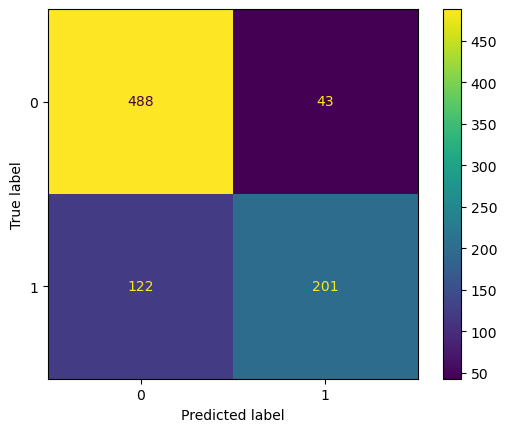

In [436]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
mplp.show()

In [437]:
# I wrote a python scriot to check the dsitribution if what I have from the confusion matrix is the same as what I have 
# in the data

apr = int(input("Please enter the Approved value: "))

rej = int(input("Please enter the Rejected value: "))

distribution = (apr /(apr + rej))

print(distribution)

if distribution >= 0.62: # This is the default distribution value from the data. 

    print("distribution is comparable to the default value")

else:

    print("distribution far from even")

Please enter the Approved value:  380
Please enter the Rejected value:  220


0.6333333333333333
distribution is comparable to the default value


In [438]:
# I want to show how well my model separates classes uising ROC curve (Model Performanace Quality)

print(y.unique())

# y = y.str.strip()

print(y.dtype)
y = y.map({
    'Rejected': 0,
    'Approved': 1
})

from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

# fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# mplp.plot(fpr, tpr)
# mplp.plot([0,1],[0,1], '--')
# mplp.xlabel("False Postive Rate")
# mplp.ylabel("True Postive Rate")
# mplp.title("ROC Curve")
# mplp.show()

[' Approved' ' Rejected']
object


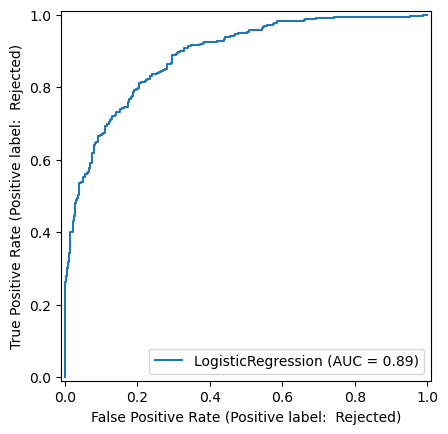

In [439]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)

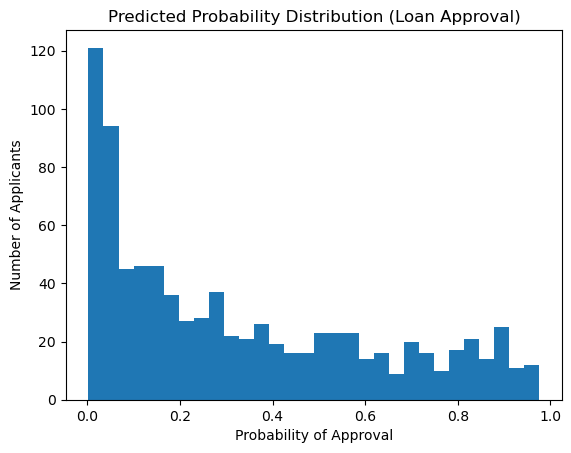

In [427]:
y_prob = model.predict_proba(X_test)[:, 1]

mplp.hist(y_prob, bins=30)
mplp.title("Predicted Probability Distribution (Loan Approval)")
mplp.xlabel("Probability of Approval")
mplp.ylabel("Number of Applicants")
mplp.show()

In [441]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("\n======================")
    print(name)
    print("Accuracey:", acc)
    print(classification_report(y_test, y_pred))


LogisticRegression
Accuracey: 0.8067915690866511
              precision    recall  f1-score   support

    Approved       0.80      0.92      0.86       531
    Rejected       0.82      0.62      0.71       323

    accuracy                           0.81       854
   macro avg       0.81      0.77      0.78       854
weighted avg       0.81      0.81      0.80       854


Decision Tree
Accuracey: 0.9765807962529274
              precision    recall  f1-score   support

    Approved       0.97      0.99      0.98       531
    Rejected       0.98      0.96      0.97       323

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.97       854
weighted avg       0.98      0.98      0.98       854


Random Forest
Accuracey: 0.9847775175644028
              precision    recall  f1-score   support

    Approved       0.98      1.00      0.99       531
    Rejected       0.99      0.97      0.98       323

    accuracy                           0.9

C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


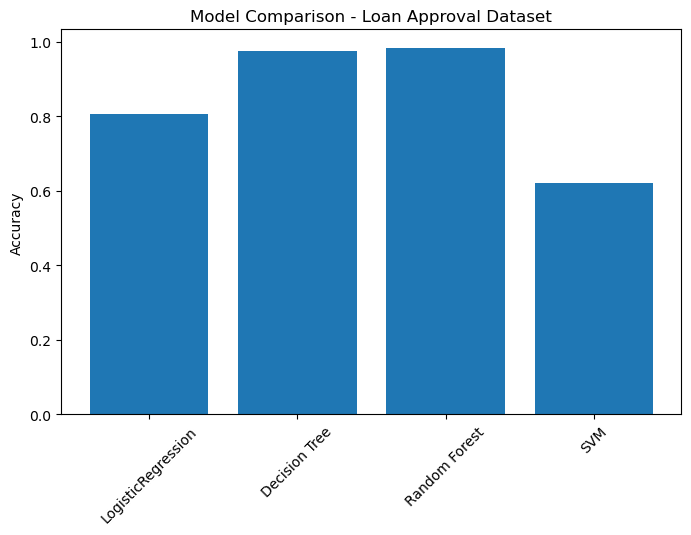

In [442]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.title("Model Comparison - Loan Approval Dataset")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.show()